In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_enable_x64', True)

import numpy as np
import matplotlib.pyplot as plt

from models import log_powerlaw_redshift
from bilby_util import LogInterped

from bilby.core.prior import Interped

from util import choose_grid

%load_ext autoreload
%autoreload 2

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import h5ify
samples = h5ify.load('./test/1703/prior.hdf5')

In [11]:
import json

with open('./parameters/o4a-strong-maxl.json', 'r') as f:
    parameters = json.loads(f.read())

(1e-05, 10.0)

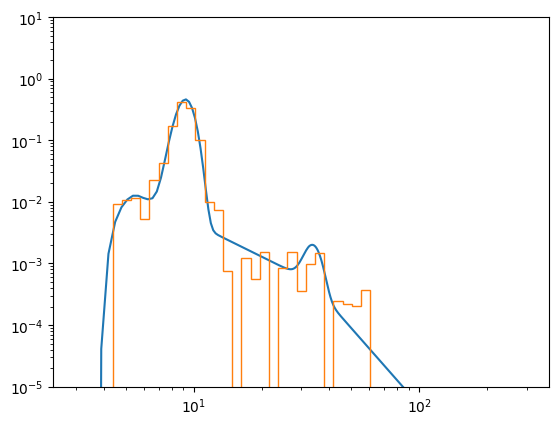

In [10]:
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth
test_m1s = np.linspace(3, 300, 1_000)
log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=test_m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)

fig, ax = plt.subplots()
ax.plot(test_m1s, np.exp(log_p_m1))
bins = np.logspace(np.log10(3), np.log10(300), 50)
ax.hist(samples['mass_1_source'], histtype='step', bins=bins, density=True)
ax.loglog()

ax.set_ylim(1e-5, 1e1)

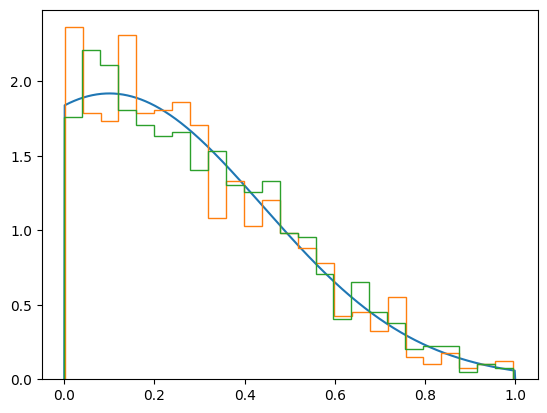

In [17]:
from models import trunc_gaussian

xs = np.linspace(0, 1, 1_000)
log_p = trunc_gaussian(xs, parameters['mu_chi'], parameters['sigma_chi'], lower=0, upper=1)

fig, ax = plt.subplots()
ax.plot(xs, np.exp(log_p))

ax.hist(samples['a_1'], histtype='step', bins=25, density=True)
ax.hist(samples['a_2'], histtype='step', bins=25, density=True);

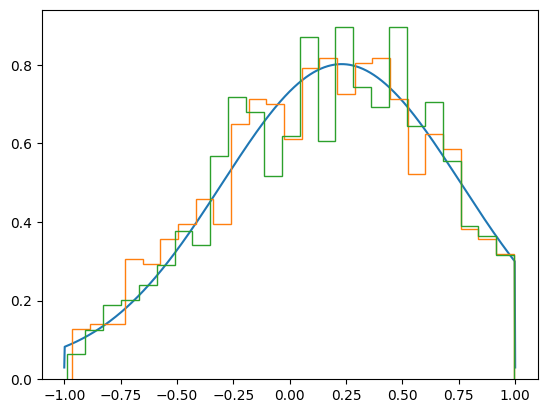

In [18]:
from models import log_marg_iso_gauss_spin_tilt

xs = np.linspace(-1, 1, 1_000)
log_p = log_marg_iso_gauss_spin_tilt(xs, parameters['xi_spin'], parameters['sigma_spin'], parameters['mu_spin'])

fig, ax = plt.subplots()
ax.plot(xs, np.exp(log_p))

ax.hist(samples['cos_tilt_1'], histtype='step', bins=25, density=True)
ax.hist(samples['cos_tilt_2'], histtype='step', bins=25, density=True);

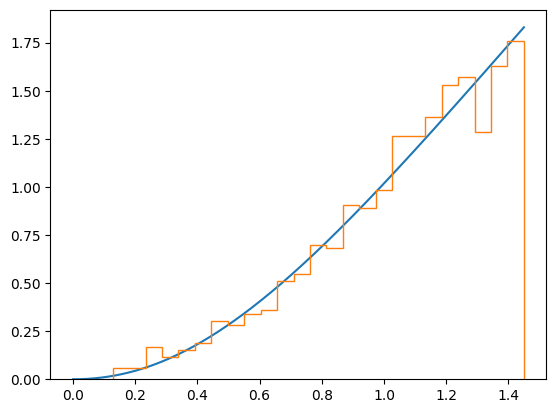

In [20]:
from models import log_powerlaw_redshift

xs = np.linspace(1e-5, 1.45, 1_000)
log_p = log_powerlaw_redshift(dict(redshift=xs), parameters)

fig, ax = plt.subplots()
ax.plot(xs, np.exp(log_p))

ax.hist(samples['redshift'], histtype='step', bins=25, density=True);

In [51]:
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio


test_m1s = np.linspace(3, 300, 500)
test_q = np.linspace(0.1, 1, 500)
mm, qq = np.meshgrid(test_m1s, test_q, indexing='ij')

log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=mm),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)

log_pm1q = log_p_m1 + PowerlawPlusPeak_MassRatio(
    dict(mass_1=mm, mass_ratio=qq),
    parameters['beta'],
    parameters['mlow_1'],
    parameters['delta_m_1']
)

In [48]:
from util import logtrapz

In [52]:
log_q = logtrapz(log_pm1q, test_m1s, axis=0)

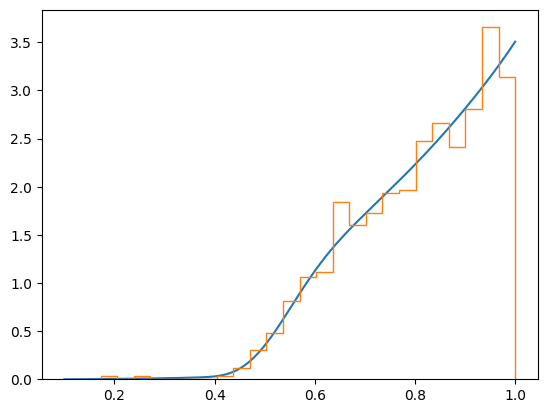

In [53]:
fig, ax = plt.subplots()
ax.plot(test_q, np.exp(log_q))
ax.hist(samples['mass_ratio'], histtype='step', bins=25, density=True);

In [33]:
samples['mass_ratio']

array([0.83777636, 0.80402484, 0.90270076, 0.61719844, 0.93778742,
       0.6521747 , 0.51917065, 0.58656745, 0.70979705, 0.97485653,
       0.98611371, 0.89971124, 0.94648218, 0.90681716, 0.7564781 ,
       0.71968644, 0.93588474, 0.99664821, 0.95559786, 0.77037267,
       0.97282333, 0.6792281 , 0.89222214, 0.63225982, 0.77177248,
       0.95450115, 0.70222035, 0.98023305, 0.57755947, 0.79743906,
       0.95701485, 0.75083173, 0.88098411, 0.83500035, 0.66863577,
       0.90252068, 0.90324791, 0.75605695, 0.97540522, 0.58862432,
       0.73543364, 0.94228187, 0.84507329, 0.64029409, 0.97392819,
       0.81058057, 0.71545881, 0.63403216, 0.45409144, 0.79707909,
       0.6544801 , 0.76532557, 0.75683006, 0.50221843, 0.87784929,
       0.6961336 , 0.90010381, 0.8297389 , 0.96171675, 0.94511105,
       0.87054953, 0.52068467, 0.74549688, 0.66167685, 0.89617104,
       0.95673669, 0.88955776, 0.98218123, 0.93838116, 0.91082969,
       0.85773589, 0.98848548, 0.62869701, 0.94650826, 0.58568

In [ ]:
parameters['mlowa_1']

3.56

In [4]:
from pixelpop.models.gwpop_models import trunc_gaussian

In [3]:
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth

@jax.jit
def log_p_m1(x):
    return BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dict(mass_1=x),
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mlow_1=parameters['mlow_1'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(
            parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
        ),
        mpp_1=parameters['mpp_1'],
        sigpp_1=parameters['sigpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_2=parameters['sigpp_2'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )

out = choose_grid(log_p_m1, 3, 300, 1e-2, n_init=5_000, n_max=10_000)

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


it 1, max err: 5000000721.845931 @ 3.5347069413882775
ngrid: 5000
it 2, max err: 5000000969.455822 @ 3.5347069413882775
ngrid: 5011
it 3, max err: 5000000969.455822 @ 3.5495599119823966
ngrid: 5025
it 4, max err: 4999999028.245556 @ 3.5569863972794558
ngrid: 5042
it 5, max err: 4999999998.850689 @ 3.5569863972794558
ngrid: 5063
it 6, max err: 4999999998.850689 @ 3.5588430186037208
ngrid: 5089
it 7, max err: 4999999998.850925 @ 3.5597713292658533
ngrid: 5122
it 8, max err: 4999999998.850925 @ 3.5597713292658533
ngrid: 5163
it 9, max err: 4999999998.850866 @ 3.5597713292658533
ngrid: 5214
it 10, max err: 4999999998.850866 @ 3.55988736809862
ngrid: 5276
it 11, max err: 4999999998.850866 @ 3.559945387515003
ngrid: 5350
it 12, max err: 4999999998.850866 @ 3.5599743972231948
ngrid: 5437
it 13, max err: 4999999998.850866 @ 3.559988902077291
ngrid: 5533
it 14, max err: 4999999998.850866 @ 3.5599961545043386
ngrid: 5629
it 15, max err: 4999999998.850866 @ 3.5599997807178623
ngrid: 5698
it 16, m

KeyboardInterrupt: 

In [3]:
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth

m1s = np.linspace(3, 300, 5_000)
log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=m1s),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)
m1_prior = LogInterped(
    m1s,
    log_p_m1,
    minimum=min(m1s),
    maximum=max(m1s),
    name='mass_1_source'
)

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
m1_prior_interped = Interped(
    m1s,
    np.exp(log_p_m1),
    minimum=min(m1s),
    maximum=max(m1s),
    name='mass_1_source'
)

In [32]:
qs = m1_prior_interped.sample(1_000_000)

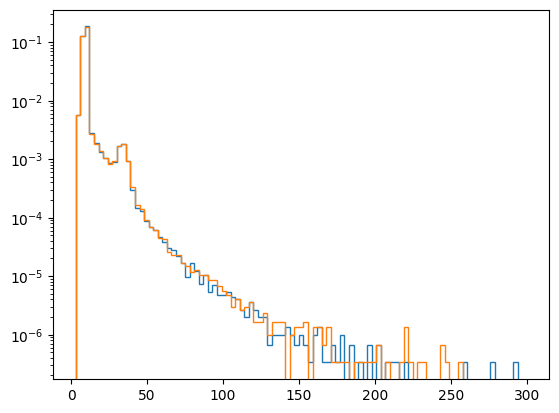

In [34]:
bins = np.linspace(3, 300, 100)

fig, ax = plt.subplots()
ax.hist(samps, histtype='step', bins=bins, density=True)
ax.hist(qs, histtype='step', bins=bins, density=True)

ax.set_yscale('log');

In [33]:
samps = m1_prior.sample(1_000_000)

In [6]:
log_p = m1_prior.ln_prob(samps)

In [7]:
log_t = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    dict(mass_1=samps),
    alpha_1=parameters['alpha_1'],
    alpha_2=parameters['alpha_2'],
    mlow_1=parameters['mlow_1'],
    break_mass=parameters['break_mass'],
    delta_m_1=parameters['delta_m_1'],
    lam_fractions=(
        parameters['lam_0'], parameters['lam_1'], parameters['lam_2']
    ),
    mpp_1=parameters['mpp_1'],
    sigpp_1=parameters['sigpp_1'],
    mpp_2=parameters['mpp_2'],
    sigpp_2=parameters['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)

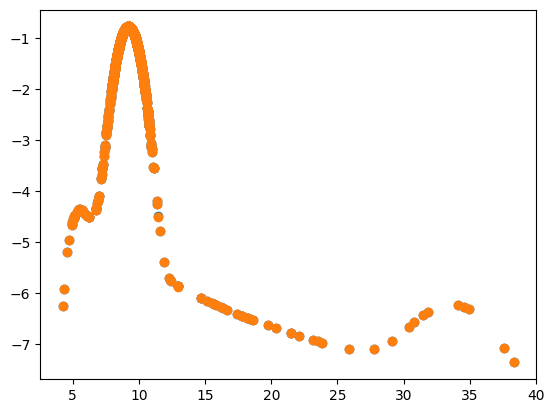

In [10]:
fig, ax = plt.subplots()
ax.scatter(
    samps,
    log_p
)
ax.scatter(
    samps,
    log_t
)

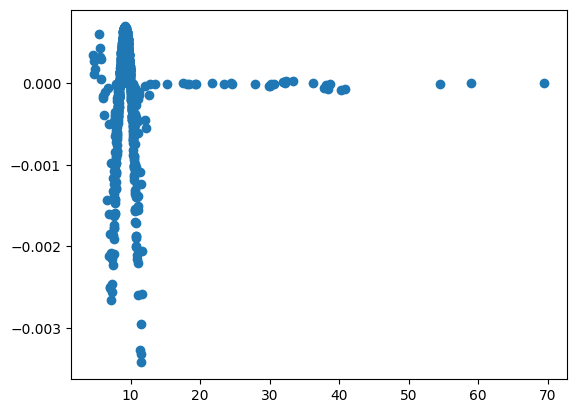

In [26]:
fig, ax = plt.subplots()
ax.scatter(
    samps,
    log_t - log_p
)

In [25]:
parameters = dict(lamb=2.61, z_max=1.45)

In [3]:
z_max = parameters['z_max']
zs = np.linspace(1e-5, z_max, 1000)
log_pz = np.array(log_powerlaw_redshift(
    dict(redshift=zs),
    parameters
))
z_prior = LogInterped(
    zs,
    log_pz,
    minimum=min(zs),
    maximum=max(zs),
    name='redshift'
)

In [4]:
s = z_prior.sample()
log_p = z_prior.ln_prob(s)

In [5]:
s, log_p

(0.7687914096820186, -0.4420050182907457)

In [6]:
log_powerlaw_redshift(dict(redshift=np.array([s])), parameters)

Array([-0.44333449], dtype=float64)

In [8]:
import jax.numpy as jnp
import jax.scipy.special as jsp
from astropy import units
import wcosmo


def log_powerlaw_redshift_unnorm(dataset, parameters):
    lamb = parameters['lamb']
    z = dataset['redshift']
    max_z = parameters.get('z_max', 1.45)

    ln_dvc_dz = jnp.log(
        4 * jnp.pi * wcosmo.Planck15.differential_comoving_volume(z).to(
            units.Gpc**3 / units.sr
        ).value
    )
    ln_p = ln_dvc_dz + (lamb - 1) * jnp.log(1. + z)

    window = jnp.logical_and(z >= 0., z <= max_z)
    return jnp.where(window, ln_p, -jnp.inf)


def log_powerlaw_redshift_normalization(dataset, parameters):
    lamb = parameters['lamb']
    z = dataset['redshift']
    max_z = parameters.get('z_max', 1.45)

    zs_fixed = np.linspace(1e-5, max_z, 1000)
    fixed_ln_dvc_dz = jnp.log(
        4 * jnp.pi * wcosmo.Planck15.differential_comoving_volume(zs_fixed).to(
            units.Gpc**3 / units.sr
        ).value
    )

    dz = zs_fixed[1] - zs_fixed[0]
    test_ln_p = fixed_ln_dvc_dz + (lamb - 1) * jnp.log(1. + zs_fixed)
    return jsp.logsumexp(test_ln_p) + jnp.log(dz)

In [9]:
z_max = parameters['z_max']
zs = np.linspace(1e-5, z_max, 1000)
log_pz_unnorm = np.array(log_powerlaw_redshift_unnorm(
    dict(redshift=zs),
    parameters
))
z_prior_unnorm = LogInterped(
    zs,
    log_pz_unnorm,
    minimum=min(zs),
    maximum=max(zs),
    name='redshift'
)

In [11]:
s = z_prior_unnorm.sample()
log_p = z_prior_unnorm.ln_prob(s)

In [12]:
s, log_p

(1.1073375772976053, 0.18830000240716224)

In [14]:
ln_norm = log_powerlaw_redshift_normalization(dict(redshift=np.array([s])), parameters)

In [15]:
ln_norm

Array(6.98931978, dtype=float64)

In [37]:
log_powerlaw_redshift_unnorm(
    dict(redshift=np.array([s])),
    parameters
) - ln_norm

NameError: name 'log_powerlaw_redshift_unnorm' is not defined

In [30]:
import h5ify

In [31]:
det = h5ify.load('./test/1702/detectable.hdf5')

In [33]:
det['log_prior_cos_tilt_1'] + det['log_prior_cos_tilt_2']

array([-0.69113255, -2.35263085, -1.12986073, -0.6246115 , -1.34479532,
       -1.0379498 , -2.08033967, -3.08148402, -0.69026721, -0.83968884])

In [38]:
from models import log_nid_iso_gauss_tilt

log_nid_iso_gauss_tilt(
    det,
    parameters
)

Array([-0.69113251, -2.35263083, -1.1298607 , -0.62461153, -1.34479529,
       -1.03794962, -2.08033966, -3.08148386, -0.69026712, -0.83968867],      dtype=float64)

In [3]:
det['log_prior_redshift']

array([-4.10211897, -1.08378215, -2.54795743, -6.60634147,  0.10677294,
       -3.31077169, -4.4527424 , -2.79810526, -3.95551044, -5.23676664])

In [4]:
from models import log_powerlaw_redshift

In [5]:
log_powerlaw_redshift(det, dict(lamb=2.61))

Array([-4.103449  , -1.0851116 , -2.5492868 , -6.607671  ,  0.10544348,
       -3.3121011 , -4.454072  , -2.7994347 , -3.9568398 , -5.238096  ],      dtype=float32)